In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

from Corrfunc import mocks
from Corrfunc.utils import convert_rp_pi_counts_to_wp
from scipy import constants
from scipy import stats
import scipy.interpolate as interp
from random import sample
import matplotlib.gridspec as gridspec
from Corrfunc import theory
from astropy.cosmology import FlatLambdaCDM
from Corrfunc.utils import convert_3d_counts_to_cf
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
from astropy.coordinates import SkyCoord
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches
from tqdm import trange
from astropy.cosmology import Planck18
import pyccl as ccl

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Load data from local machine

In [3]:
fn_sello = f'../data/maps/selection_function_NSIDE64_G20.0.fits'
fn_selhi = f'../data/maps/selection_function_NSIDE64_G20.5.fits'

## Parameters

In [4]:
NSIDE = 64
NPIX = hp.nside2npix(NSIDE)

In [5]:
G_hi = 20.5

In [6]:
nthreads = 18

In [7]:
mask_type = 'selfunc'

# Visuals

In [8]:
tab_datahi, pixel_indices_datahi_mask, N_datahi_mask, mask_datahi = quaia.read(f'../data/quaia_G20.5.fits', G_hi, fn_selhi, mask_type = 'selfunc')

Number of data sources: 1295502
{'NAME': '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog', 'ABBRV': 'Quaia'}
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


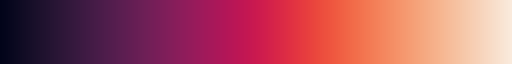

In [9]:
cmap = sns.color_palette("rocket", as_cmap=True)
cmap

In [10]:
zbin_array = [0.0,1.0,2.0,3.0,4.0]

<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_244730/2690018502.py:18: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel('N$_\mathrm{QSO}$')
/tmp/ipykernel_244730/2690018502.py:26: SyntaxWarning: invalid escape sequence '\m'
  ax3.set_xlabel('N$_\mathrm{QSO}$')


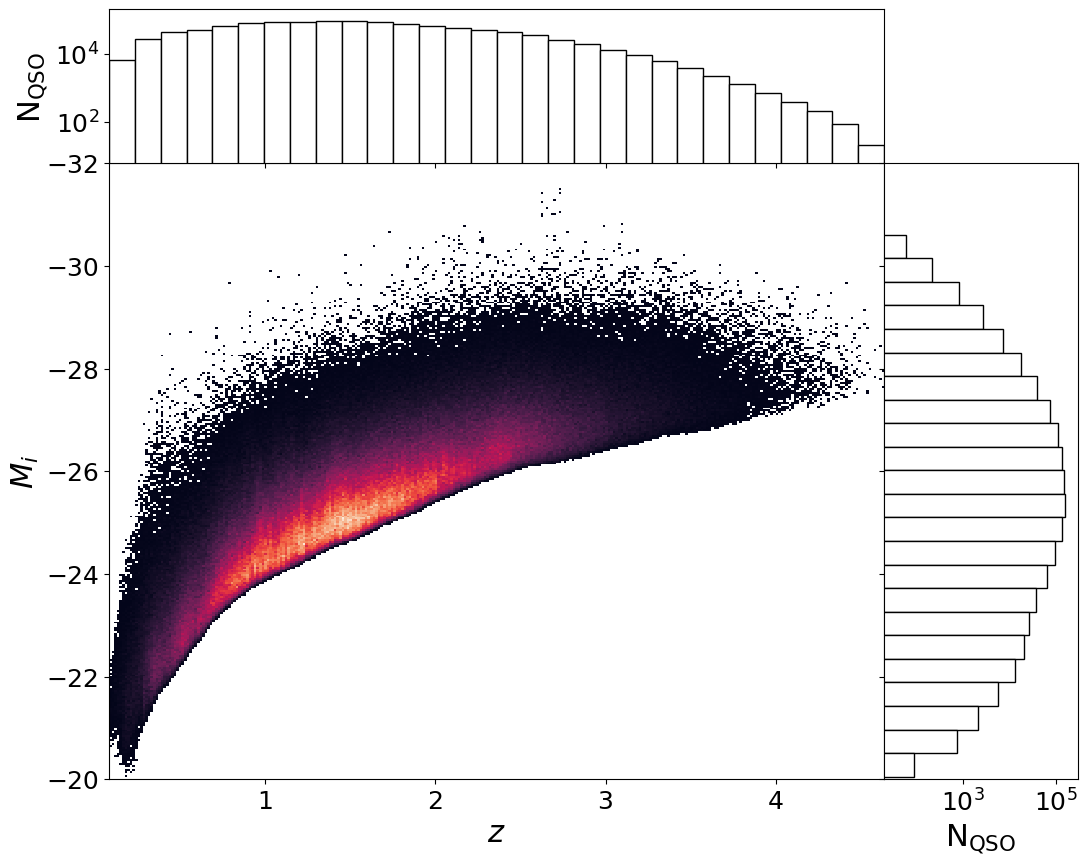

In [11]:
# plot!
fig = plt.figure(figsize = (12.5, 10))
gs = gridspec.GridSpec(2, 2, hspace = 0, height_ratios=[1,4], width_ratios=[4,1], wspace = 0)

ax1 = fig.add_subplot(gs[2])

quaia.absolute(tab_datahi, G_hi)
h1, xedges, yedges, image = ax1.hist2d(tab_datahi['redshift_quaia'][mask_datahi], tab_datahi['M_i'][mask_datahi], cmap = cmap, bins = 300, 
                                       cmin = 1)
ax1.set_ylabel('$M_i$')
ax1.set_xlabel('$z$')
ax1.set_ylim(-20, -32)
xlim = ax1.get_xlim()
ylim = ax1.get_ylim()

ax2 = fig.add_subplot(gs[0])
ax2.hist(tab_datahi['redshift_quaia'][mask_datahi], color = 'white', edgecolor = 'black', bins = 30)
ax2.set_ylabel('N$_\mathrm{QSO}$')
ax2.set_yscale('log')
ax2.set_xlim(xlim)
ax2.set_ylim(6,2e5)
ax2.set_xticklabels([])

ax3 = fig.add_subplot(gs[3])
ax3.hist(tab_datahi['M_i'][mask_datahi], color = 'white', edgecolor = 'black', orientation = 'horizontal', bins = 25)
ax3.set_xlabel('N$_\mathrm{QSO}$')
ax3.set_xscale('log')
ax3.set_yticklabels([])
ax3.set_ylim(ylim)
ax3.set_xlim(2e1,3e5)

plt.show()

# Compute clustering in four z bins
## $w(\theta)$

In [12]:
# Create the bins array
rmin = 0.1
rmax = 25
nbins = 14
thetabins = np.logspace(np.log10(rmin), np.log10(rmax), nbins+1) #(np.log10(0.15), np.log10(35), 15)

In [13]:
zbin_array = [0.0,1.0,2.0,3.0,4.0]
cmap_blue = plt.get_cmap('Blues')(np.linspace(0.333, 0.999, len(zbin_array)-1))

In [14]:
cosmo_planck18 = ccl.Cosmology(Omega_c=0.265, Omega_b=Planck18.Ob0, h=Planck18.h, Neff = Planck18.Neff, T_CMB = Planck18.Tcmb0.value, m_nu = Planck18.m_nu, sigma8=0.8, n_s=0.95)

In [15]:
Om0 = {'Planck': cosmo_planck18['Omega_m'], 'Quaia': 0.343}

In [17]:
N = 25

## Pick cosmology

In [16]:
cosmo = 'Planck'

<>:39: SyntaxWarning: invalid escape sequence '\l'
<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:39: SyntaxWarning: invalid escape sequence '\l'
<>:47: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_21051/3698340039.py:39: SyntaxWarning: invalid escape sequence '\l'
  ax1.hist(tab_datahi_mask_zbin0['redshift_quaia'], label = '${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1),
/tmp/ipykernel_21051/3698340039.py:47: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel('$N_\mathrm{QSO}$')


G20.5_zmin0.0zmax1.0: 0.30              225792 vs 324336


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


DD: 1.128698
DR: 57.627948
RR: 666.624926
G20.5_zmin1.0zmax2.0: 0.28              467913 vs 648196


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


DD: 2.7044509999999997
DR: 230.207115
RR: 2978.588085
G20.5_zmin2.0zmax3.0: 0.24              216828 vs 286508


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


DD: 1.098169
DR: 53.669219
RR: 554.249531
G20.5_zmin3.0zmax4.0: 0.21              28061 vs 35630


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


DD: 0.015153
DR: 0.6038479999999999
RR: 4.242308


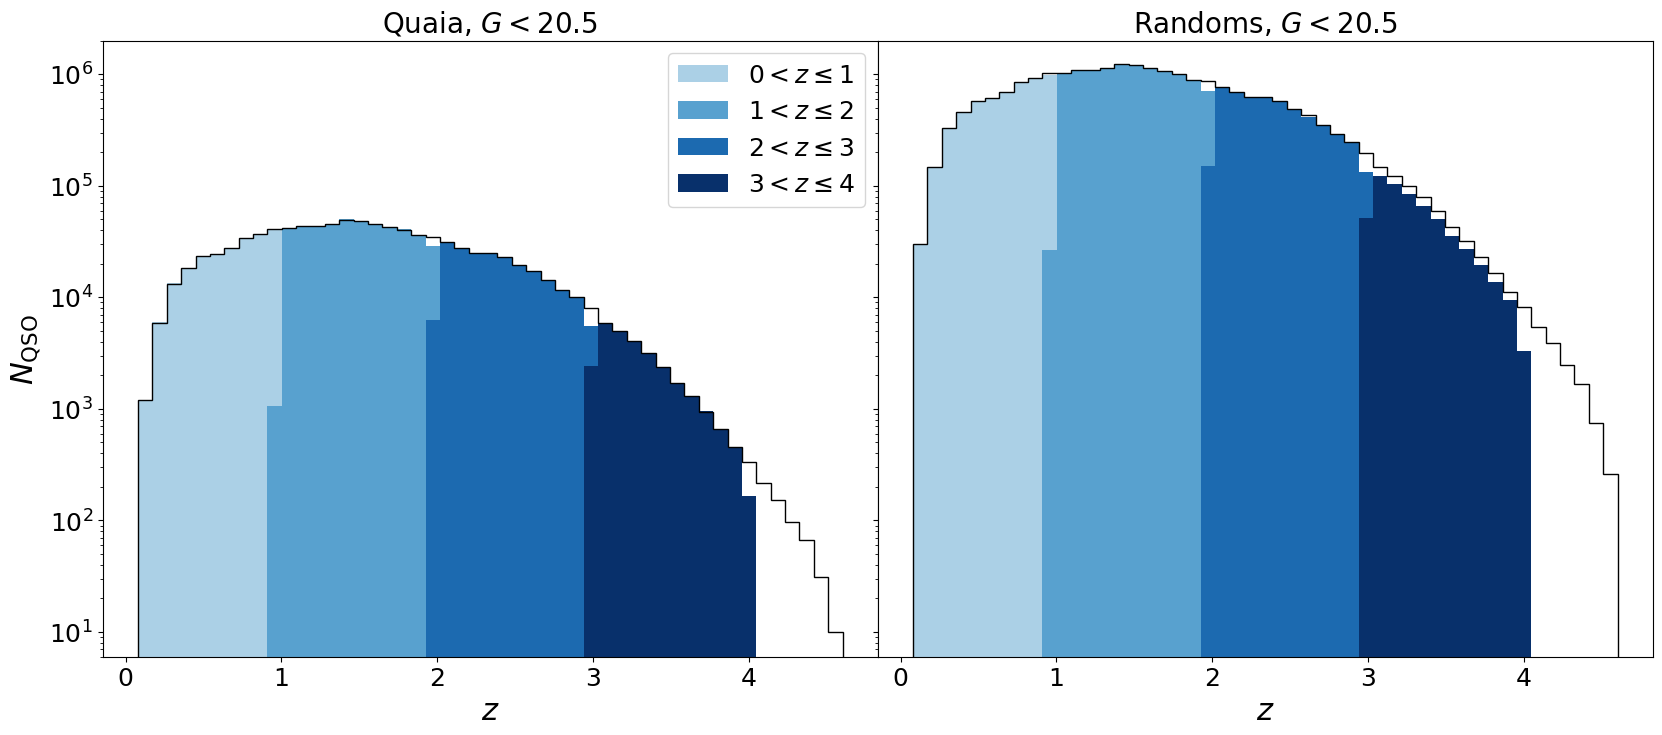

In [17]:
# plot data
bins = np.linspace(0.08, 4.6)
wp, rpavg = [], []
fac_rand = 25
mask = 0.5
fn_selhi = '../data/maps/selection_function_NSIDE64_G{}.fits'.format(G_hi)
selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

fn_datahi = '../data/quaia_G{}.fits'.format(G_hi)
tab_datahi = Table.read(fn_datahi)
pixel_indices_datahi = hp.ang2pix(NSIDE, tab_datahi['ra'], tab_datahi['dec'], lonlat=True)
mask_datahi = selfunc_hi[pixel_indices_datahi]>=np.percentile(selfunc_hi, mask*100)

# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

ax1 = fig.add_subplot(gs[0])
ax1.hist(tab_datahi['redshift_quaia'][mask_datahi], bins=bins, histtype = 'step', color='black')

# plot randoms  
ax2 = fig.add_subplot(gs[1])

# for comparison purposes
fn_randhi = '../data/randoms/random_G{}_{}x.fits'.format(G_hi, fac_rand)
tab_randhi = Table.read(fn_randhi)
pixel_indices_randhi = hp.ang2pix(NSIDE, tab_randhi['ra'], tab_randhi['dec'], lonlat=True)
mask_randhi = selfunc_hi[pixel_indices_randhi]>=np.percentile(selfunc_hi, mask*100)
N_randhi_mask = len(tab_randhi['ra'][mask_randhi])
N_datahi_mask = len(tab_datahi['ra'][mask_datahi])
quaia.z_dist(tab_datahi, tab_randhi, mask_datahi, mask_randhi, N_datahi_mask, N_randhi_mask, mask_type = mask_type)
ax2.hist(tab_randhi['redshift_quaia_'+mask_type], histtype = 'step', bins = bins, 
         color = 'black')

for zbin in zbin_array[:-1]:
    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G_hi, int(zbin),True, 'z', bins = zbin_array, 
                                                                                       tab_gcat_type = 'data', method = 'minmax', 
                                                                                    fac_rand = fac_rand, mask = mask*100, percentile = True)
    ax1.hist(tab_datahi_mask_zbin0['redshift_quaia'], label = '${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1), 
             bins = bins, color = cmap_blue[int(zbin)])
    ax2.hist(tab_randhi_mask_zbin0['redshift_quaia_{}'.format(key_zbin0)], label = 'bin{}'.format(zbin),
             bins = bins, color = cmap_blue[int(zbin)])

    wp.append(quaia.w_theta(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, nthreads = nthreads, thetabins = thetabins))

ax1.set_xlabel('$z$')
ax1.set_ylabel('$N_\mathrm{QSO}$')
ax1.set_yscale('log')
ax1.set_ylim(6,2e6)
ax1.set_title('Quaia, $G<{}$'.format(G_hi))
ax1.legend()

ax2.set_xlabel('$z$')
ax2.set_yscale('log')
ax2.set_ylim(6,2e6)
ax2.set_title('Randoms, $G<{}$'.format(G_hi))
ax2.set_yticklabels([])
plt.show()

# Use delete-one jackknife resampling
## Split the sky into RA stripes

In [18]:
ra_bins = np.linspace(0, 360, N+1)
for i in range(N):
    
    delete = (tab_datahi_mask_zbin0['ra']>=ra_bins[i+1]) | (tab_datahi_mask_zbin0['ra'] <ra_bins[i])
    print(np.unique(np.digitize(tab_datahi_mask_zbin0['ra'][delete], ra_bins)))

[ 2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  5  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  5  6  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  5  6  7  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  5  6  7  8 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  5  6  7  8  9 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  5  6  7  8  9 10 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  5  6  7  8  9 10 11 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  5  6  7  8  9 10 11 12 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  5  6  7  8  9 10 11 12 1

## Compute $w_p(r_p)$ in each jackknife bin

In [ ]:
wp_jackknife, rpavg_jackknife = {zbin: [] for zbin in zbin_array[:-1]}, {zbin: [] for zbin in zbin_array[:-1]}

for zbin in zbin_array[:-1]:
    
    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G_hi, int(zbin),True, 'z', bins = zbin_array, 
                                                                                       tab_gcat_type = 'data', method = 'minmax', 
                                                                                    fac_rand = fac_rand, mask = mask*100, percentile = True)

    for i in trange(N):
    
        jackknife_data = (tab_datahi_mask_zbin0['ra'] >= ra_bins[i+1]) | (tab_datahi_mask_zbin0['ra'] < ra_bins[i])
        jackknife_rand = (tab_randhi_mask_zbin0['ra'] >= ra_bins[i+1]) | (tab_randhi_mask_zbin0['ra'] < ra_bins[i])

        wp_jackknife[zbin].append(quaia.w_theta(tab_datahi_mask_zbin0[jackknife_data], tab_randhi_mask_zbin0[jackknife_rand], nthreads = nthreads, thetabins = thetabins))

G20.5_zmin0.0zmax1.0: 0.30              225792 vs 324336


  0%|          | 0/25 [00:00<?, ?it/s]/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


DD: 0.596545
DR: 46.41397


  4%|▍         | 1/25 [10:07<4:02:52, 607.17s/it]

RR: 553.798165
DD: 0.530057
DR: 27.440946


...

RR: 1576.094457
DD: 2.46602
DR: 124.681234


 36%|███▌      | 9/25 [4:05:09<7:26:30, 1674.40s/it]

RR: 1517.817596
DD: 2.349577
DR: 122.079491


 40%|████      | 10/25 [4:31:46<6:52:38, 1650.54s/it]

RR: 1462.019877
DD: 2.339692
DR: 117.040513


## Compute the jackknife covariance matrix
### \begin{array}{r}
C_{i j}=\frac{N-1}{N} \sum_{k=1}^N\left[\xi^{(k)}\left(s_{i}\right)-\bar{\xi}\left(s_{i}\right)\right] \\
{\left[\xi^{(k)}\left(s_{j}\right)-\bar{\xi}\left(s_{j}\right)\right]}
\end{array}

In [ ]:
C = {zbin: [] for zbin in zbin_array[:-1]}
for zbin in zbin_array[:-1]:
    
    wp_mean = np.nanmean(wp_jackknife[zbin], axis = 0)  # is it ok to ignore nan values?
    delta = wp_jackknife[zbin]-wp_mean
    C[zbin] = (N-1)/N*(delta.T @ delta)

## Save the full covariance

In [ ]:
for zbin in zbin_array[:-1]:
    
    np.save('../results/cov_w_theta_G{}_rmin{}_rmax{}_nbins{}_z{}_N{}'.format(G_hi, rmin, rmax, nbins, zbin, N), C[zbin])

# Plot

<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_244730/4111522571.py:7: SyntaxWarning: invalid escape sequence '\l'
  plt.errorbar(r, wp, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1),
/tmp/ipykernel_244730/4111522571.py:10: SyntaxWarning: invalid escape sequence '\l'
  plt.errorbar(r, wp[int(zbin)], marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1),


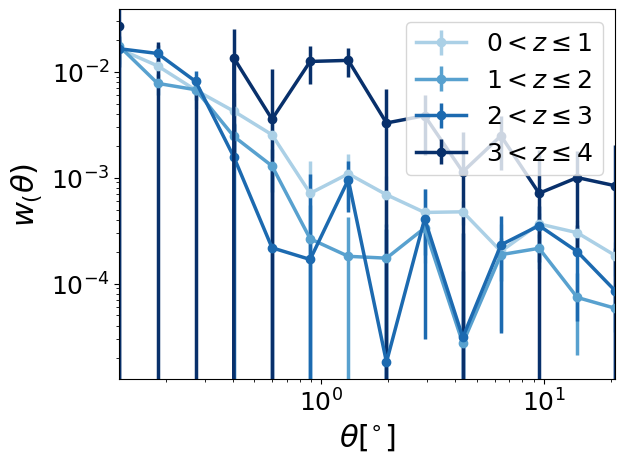

In [37]:
# plot!
r = quaia.recenter(thetabins)
for zbin in zbin_array[:-1]:
    sigma = np.sqrt(np.diag(np.load('../results/cov_w_theta_G{}_rmin{}_rmax{}_nbins{}_z{}_N{}.npy'.format(G_hi, rmin, rmax, nbins, zbin, N))))
    wp = np.load('../results/w_theta_G{}_rmin{}_rmax{}_nbins{}_z{}_N{}.npy'.format(G_hi, rmin, rmax, nbins, zbin, N))
    if len(wp) == nbins:
        plt.errorbar(r, wp, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1), 
             linewidth = 2.5, color = cmap_blue[int(zbin)], yerr = sigma) # np.sqrt(np.diag(C[zbin])))
    else:
        plt.errorbar(r, wp[int(zbin)], marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1), 
                 linewidth = 2.5, color = cmap_blue[int(zbin)], yerr = sigma) # np.sqrt(np.diag(C[zbin])))
    plt.xlabel(r'$\theta[^{\circ}]$') # projected
    # if scale == 'log':
    plt.xscale('log')
    plt.yscale('log')
    plt.xlim(r[0], r[-1])
    plt.legend()
    plt.ylabel(r"$w_(\theta)$")
plt.show()

<>:15: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:15: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_244730/3968145974.py:15: SyntaxWarning: invalid escape sequence '\l'
  ax1.errorbar(r, wp, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1),
/tmp/ipykernel_244730/3968145974.py:18: SyntaxWarning: invalid escape sequence '\l'
  ax1.errorbar(r, wp[int(zbin)], marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1),
/tmp/ipykernel_244730/3968145974.py:21: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1))


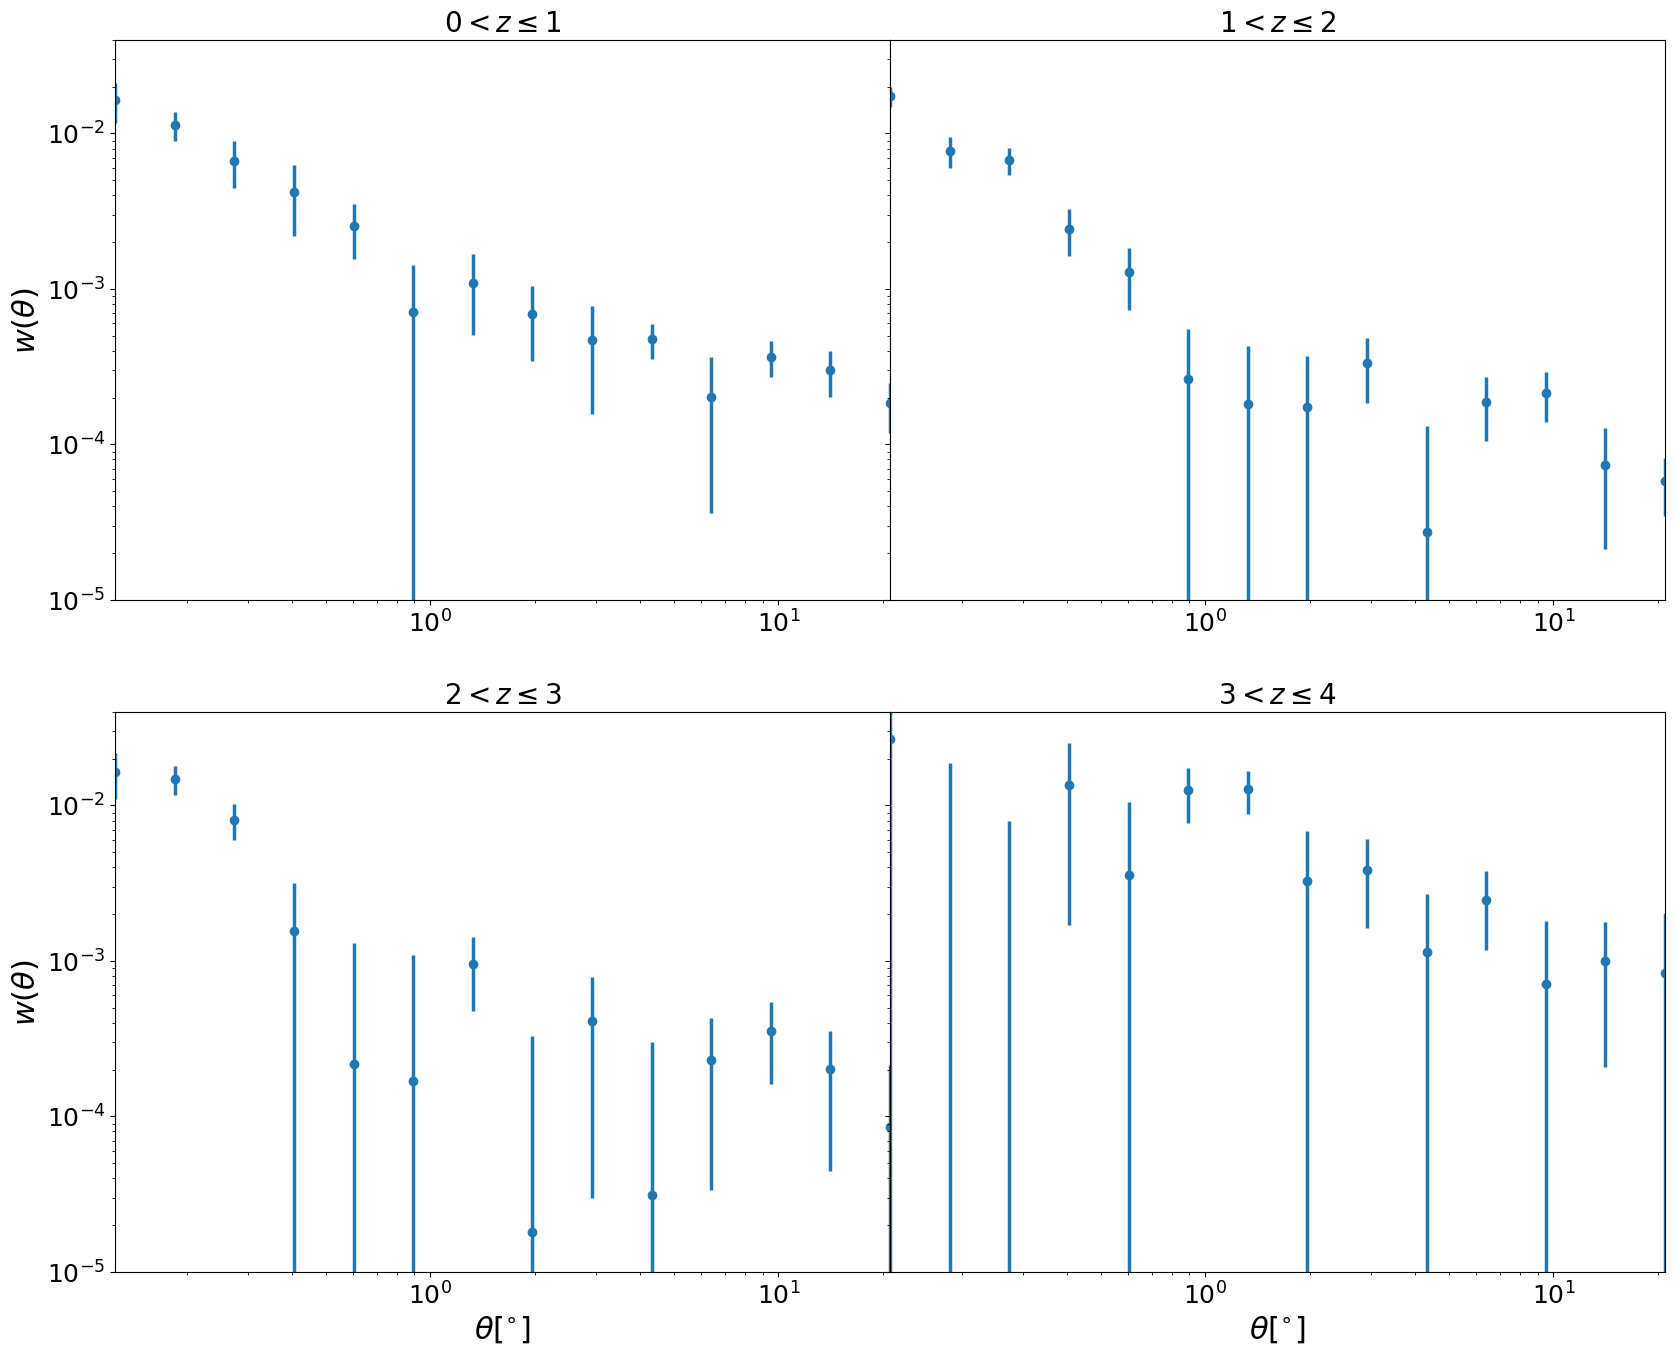

In [45]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.2)
ymin, ymax = [], []
ax=[]
for zbin in zbin_array[:-1]:
    
    ax1 = fig.add_subplot(gs[int(zbin)])
    ax.append(ax1)
        
    sigma = np.sqrt(np.diag(np.load('../results/cov_w_theta_G{}_rmin{}_rmax{}_nbins{}_z{}_N{}.npy'.format(G_hi, rmin, rmax, nbins, zbin, N))))
    wp = np.load('../results/w_theta_G{}_rmin{}_rmax{}_nbins{}_z{}_N{}.npy'.format(G_hi, rmin, rmax, nbins, zbin, N))

    if len(wp) == nbins:
        ax1.errorbar(r, wp, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1), 
             linewidth = 2.5, yerr = sigma, linestyle = 'None')
    else:
        ax1.errorbar(r, wp[int(zbin)], marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1), 
             linewidth = 2.5, yerr = sigma, linestyle = 'None')

    ax1.set_title('${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1))
    # if scale == 'log':
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(r[0], r[-1])
    # ax1.set_ylim(2.2e-1, 3.3e3)
    ax1.set_ylim(1e-5, 4e-2)
    if zbin>1:
        ax1.set_xlabel(r'$\theta[^{\circ}]$')
    if zbin%2==0:
        ax1.set_ylabel(r"$w(\theta)$")
    else:
        ax1.set_yticklabels([])

plt.show()